# LEC05. 딥러닝 CNN_ CatDog

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split                     

#----------------------------------------------------------------------------------- ML모델 
#----------------------------------------------------------------------------------  DL모델 
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, Rescaling
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D
#----------------------------------------------------------------------------------- 평가
from tensorflow.keras.initializers import GlorotNormal # Xavier
from tensorflow.keras.applications import MobileNetV2  # 최소 이미지 크기 (32*32)

#----------------------------------------------------------------------------------  조기종료
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

import tensorflow as tf
tf.random.set_seed(54546)
np.random.seed(54546)




import warnings
warnings.filterwarnings('ignore')

sns.set()

#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

#-------------------- 주피터 , 출력결과 넓이 늘리기 ---------------
# from IPython.core.display import display, HTML
from IPython.display import display, HTML
display(HTML("<style>.container{width:100% !important;}</style>"))
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('max_colwidth', None)

## Data load

In [10]:
import os

img_ext = ('.jpg', '.jpeg', '.png', '.gif', '.bmp', '.webp')
images = './dataset/catdog/train/cat/'

img_list = [
os.path.join(images, f)
    for f in os.listdir(images)
    if f.lower().endswith(img_ext)
    ]
print(len(img_list))
print(img_list)

301
['./dataset/catdog/train/cat/cat.0.jpg', './dataset/catdog/train/cat/cat.1.jpg', './dataset/catdog/train/cat/cat.10.jpg', './dataset/catdog/train/cat/cat.100.jpg', './dataset/catdog/train/cat/cat.101.jpg', './dataset/catdog/train/cat/cat.102.jpg', './dataset/catdog/train/cat/cat.103.jpg', './dataset/catdog/train/cat/cat.104.jpg', './dataset/catdog/train/cat/cat.105.jpg', './dataset/catdog/train/cat/cat.106.jpg', './dataset/catdog/train/cat/cat.107.jpg', './dataset/catdog/train/cat/cat.108.jpg', './dataset/catdog/train/cat/cat.109.jpg', './dataset/catdog/train/cat/cat.11.jpg', './dataset/catdog/train/cat/cat.110.jpg', './dataset/catdog/train/cat/cat.111.jpg', './dataset/catdog/train/cat/cat.112.jpg', './dataset/catdog/train/cat/cat.113.jpg', './dataset/catdog/train/cat/cat.114.jpg', './dataset/catdog/train/cat/cat.115.jpg', './dataset/catdog/train/cat/cat.116.jpg', './dataset/catdog/train/cat/cat.117.jpg', './dataset/catdog/train/cat/cat.118.jpg', './dataset/catdog/train/cat/cat.119

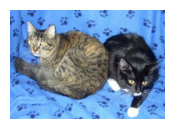

In [14]:
from PIL import Image
plt.figure(figsize=(2,2))
img = Image.open(img_list[60])
plt.imshow(img)
plt.grid(False)
plt.axis(False)
plt.show()

``` python
keras.utils.load_img(
    path,
    color_mode="rgb",
    target_size=None,
    interpolation="nearest",
    keep_aspect_ratio=False,
)

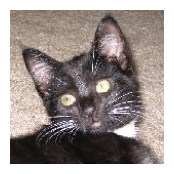

In [20]:
from tensorflow.keras.utils import load_img
images = './dataset/catdog/train/cat/cat.102.jpg'

plt.figure(figsize=(2,2))
img = load_img(images, target_size=(150, 150))
plt.imshow(img)
plt.grid(False)
plt.axis(False)
plt.show()

``` python

keras.utils.image_dataset_from_directory(
    directory,
    labels="inferred",
    label_mode="int",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format="tf",
    verbose=True,
)


In [42]:
from tensorflow.keras.utils import image_dataset_from_directory
images = './dataset/catdog/train/'

train_dir = image_dataset_from_directory(images,
                                         image_size=(150,150),
                                         label_mode="binary",
                                         seed = 4894,
                                         validation_split=0.2,
                                         batch_size=32,
                                         subset='training'
                                        )

val_dir = image_dataset_from_directory(images,
                                         image_size=(150,150),
                                         label_mode="binary",
                                         seed = 4894,
                                         validation_split=0.2,
                                         batch_size=32,
                                         subset='validation'
                                        )
                                         

Found 602 files belonging to 2 classes.
Using 482 files for training.
Found 602 files belonging to 2 classes.
Using 120 files for validation.


## Date Set

## 전처리 & 가공
 * 컬러, 노이즈, 채도, 리사이징으로 보정
 * 픽셀 -> (0 ~ 255)스케일링 필요 -> MinMaxScaler(모든 데이터를 0 ~ 1사이 숫자로) ;
           MinMaxScaler 대신 사용하는 방식 x_train = x_train / 255.0
 * 이미지 증강( augmentation)

## 모델링

In [43]:
model = Sequential([
    Rescaling(1.0/255.0, input_shape=(150,150,3)),
    Conv2D(filters=16, kernel_size=(5,5), activation='relu' ),
    MaxPooling2D(pool_size=(2,2) ),
    Conv2D(filters=32, kernel_size=(5,5), activation='relu' ),
    MaxPooling2D(pool_size=(2,2) ),
    Conv2D(filters=64, kernel_size=(5,5), activation='relu' ),
    MaxPooling2D(pool_size=(2,2) ),
    Flatten(),
    Dense(units=256, activation='relu'),
    Dense(units=1, activation='sigmoid')
    ])

In [44]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)              │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 146, 146, 16)        │           1,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 73, 73, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 69, 69, 32)          │          12,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 34, 34, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 30, 30, 64)          │          51,264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 15, 15, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 14400)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 256)                 │       3,686,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,752,225 (14.31 MB)

 Trainable params: 3,752,225 (14.31 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
model.compile(loss="binary_crossentropy" , optimizer="adam",  metrics=["accuracy"])

In [46]:
res = model.fit(train_dir,     epochs=10  , validation_data=val_dir)
# res
loss,acc = model.evaluate(train_dir)
print(f"acc : {acc:.4f} , loss:{loss:.4f} " )

Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - accuracy: 0.4855 - loss: 0.8985 - val_accuracy: 0.5500 - val_loss: 0.6891
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.5249 - loss: 0.6932 - val_accuracy: 0.5167 - val_loss: 0.6929
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.5664 - loss: 0.6872 - val_accuracy: 0.5333 - val_loss: 0.6880
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.5290 - loss: 0.6952 - val_accuracy: 0.5833 - val_loss: 0.6817
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.5581 - loss: 0.6812 - val_accuracy: 0.4750 - val_loss: 0.7499
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.5851 - loss: 0.6828 - val_accuracy: 0.5250 - val_loss: 0.6952
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.5622 - loss: 0.6734 - val_accuracy: 0.5667 - val_loss: 0.6926
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.6701 - loss: 0.6246 - val_accuracy: 0.5833 - v

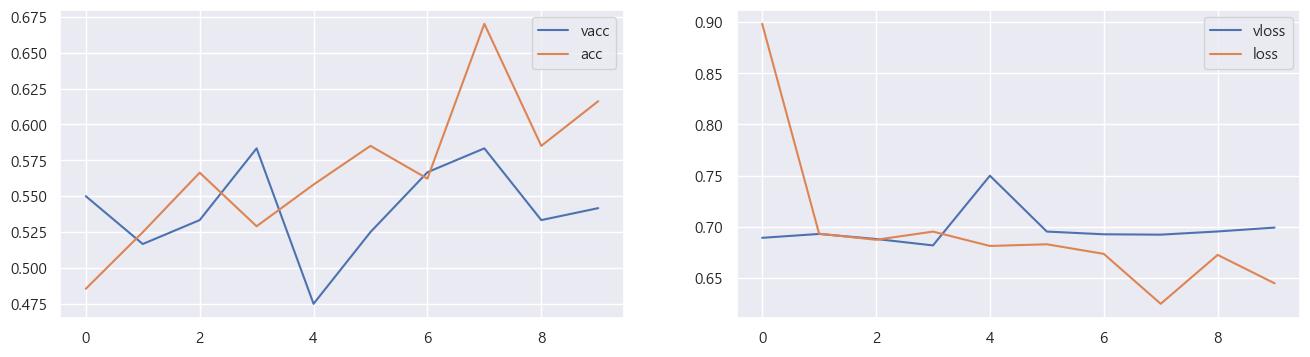

In [48]:
plt.figure(figsize=(16,4))
plt.subplot(1,2,1)
vacc = res.history["val_accuracy"]
acc  = res.history["accuracy"]
plt.plot(range(10), vacc , label="vacc")
plt.plot(range(10), acc  , label="acc")
plt.legend()

plt.subplot(1,2,2)
vloss = res.history["val_loss"]
loss = res.history["loss"]
plt.plot(range(10),vloss , label="vloss")
plt.plot(range(10),loss  , label="loss")
plt.legend()
plt.show()

# <font color=red><b>전이학습
* <b>ILSVRC(ImageNet Large Scale Visual Recognition Challenge)</b>
    - Train : 약 128만 장
    - Validation : 5만 장
    - Test : 10만 장
    - 총 클래스 : 1000개
    - https://www.image-net.org/challenges/LSVRC/
* <b>전이학습</b>
    - 잘 알려진 모델을 가져와 내 데이터에 맞게 모델을 튜닝해서 학습하는 것
    - https://keras.io/api/applications/mobilenet/mobilenet_models/#mobilenetv2-function

https://blog.kakaocdn.net/dn/OzIUv/btrs8AsKuH8/OHHLKL2orZNqyaoCzuckJ0/img.png